  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

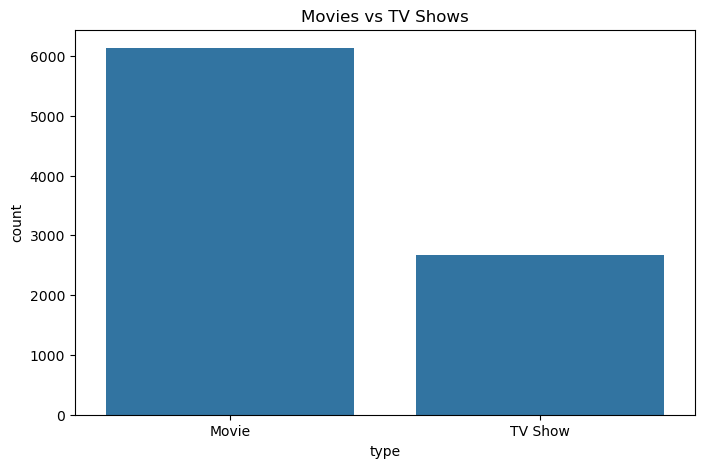

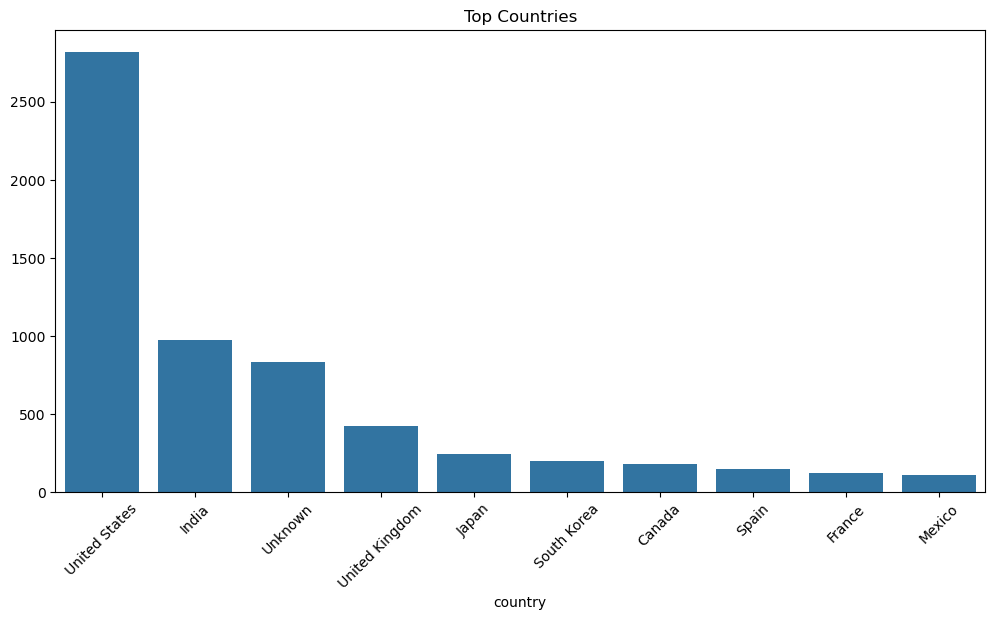

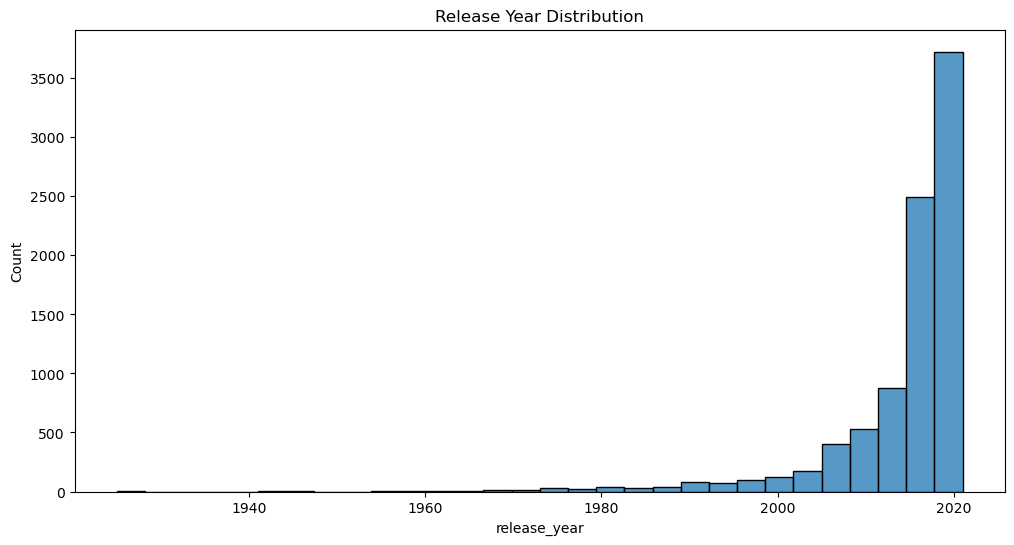

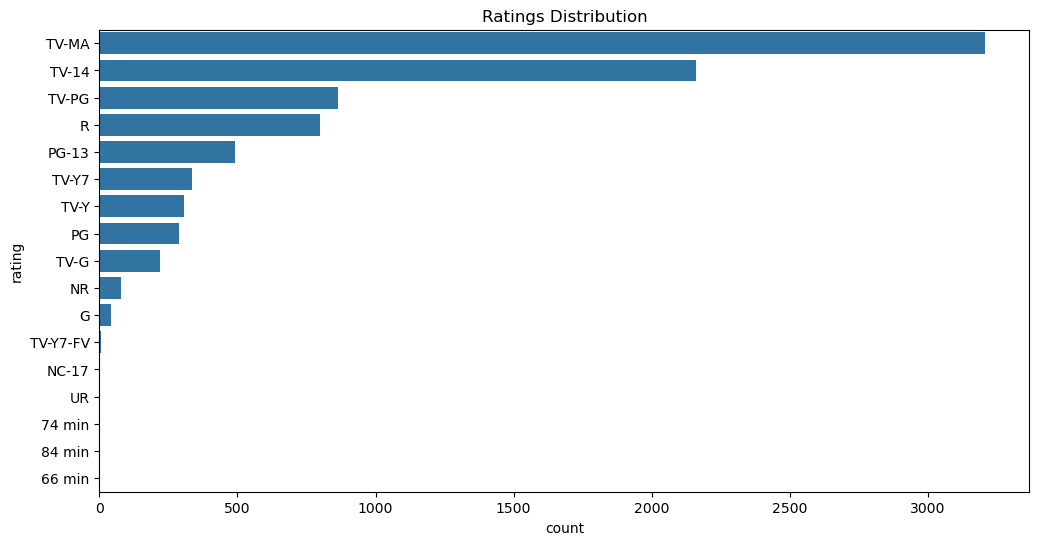

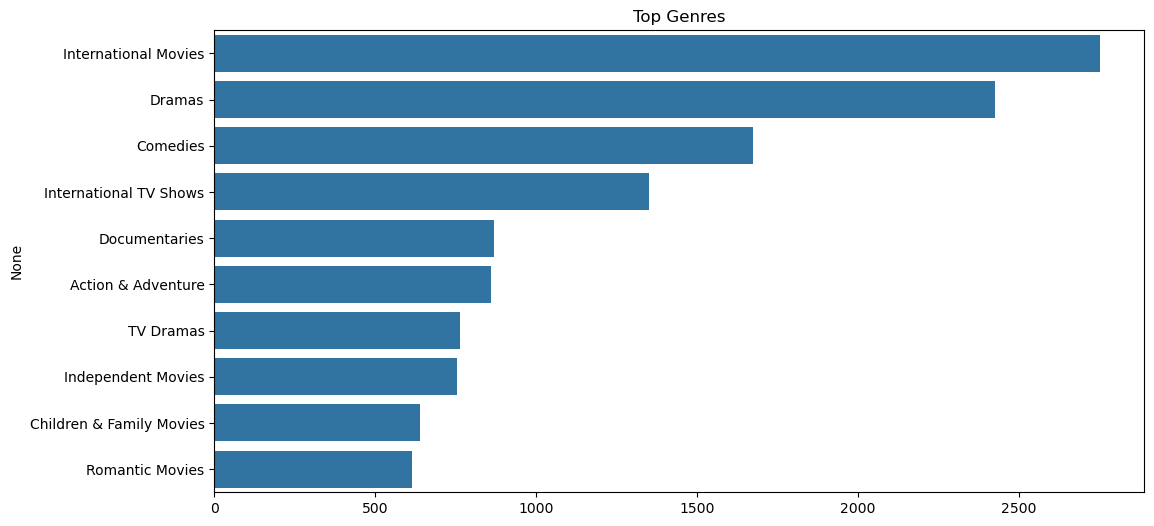

In [1]:
# ==========================================
# NETFLIX EDA PROJECT
# ==========================================

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CREATE FOLDERS
# ==========================================

os.makedirs(
    "../../../datasets/cleaned/netflix",
    exist_ok=True
)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(
    "../../../datasets/raw/netflix/netflix_titles.csv"
)

print(df.head())

# ==========================================
# BASIC INFO
# ==========================================

print("\nSHAPE")
print(df.shape)

print("\nINFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

# ==========================================
# CLEANING
# ==========================================

df = df.drop_duplicates()

df["country"] = df["country"].fillna(
    "Unknown"
)

df["director"] = df["director"].fillna(
    "Unknown"
)

df["cast"] = df["cast"].fillna(
    "Unknown"
)

# ==========================================
# SAVE CLEANED DATASET
# ==========================================

df.to_csv(
    "../../../datasets/cleaned/netflix/cleaned_netflix.csv",
    index=False
)

# ==========================================
# TOP CONTENT TYPES
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    x=df["type"]
)

plt.title("Movies vs TV Shows")

plt.show()

# ==========================================
# TOP COUNTRIES
# ==========================================

top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.xticks(rotation=45)

plt.title("Top Countries")

plt.show()

# ==========================================
# RELEASE YEAR DISTRIBUTION
# ==========================================

plt.figure(figsize=(12,6))

sns.histplot(
    df["release_year"],
    bins=30
)

plt.title("Release Year Distribution")

plt.show()

# ==========================================
# TOP RATINGS
# ==========================================

plt.figure(figsize=(12,6))

sns.countplot(
    y=df["rating"],
    order=df["rating"].value_counts().index
)

plt.title("Ratings Distribution")

plt.show()

# ==========================================
# TOP GENRES
# ==========================================

genres = df["listed_in"].str.split(
    ", ",
    expand=True
).stack()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top Genres")

plt.show()

# ==========================================
# END
# ==========================================